# NuAncestor Telescope Visibility: Requirements Comparison

This notebook compares telescope visibility results obtained from six FreeFlyer simulations. Three semi-major axes are considered: 19,300 km, 23,200 km, and 28,750 km. For each orbit, the results obtained using the original telescope requirements are compared with those obtained using relaxed requirements.

The original requirements use a minimum elevation of 36° and a maximum elevation tracking speed of 10 arcsec/s. The relaxed requirements use a minimum elevation of 30° and a maximum elevation tracking speed of 15 arcsec/s.

Version 06/2026 by Pedro de S. C. Leonardo

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path
from IPython.display import display

In [11]:
# Main folder containing the six simulation folders
BASE = Path("All_Results/RelaxedParamsCompared")

# Settings to change !!
DAYS = 30
SAVE_FIGURES = False
SHOW_REQUIREMENTS = False

In [12]:
stations = ["Chile", "La Palma", "Hawaii", "SALT", "DAG"]
colors = ["r", "blueviolet", "cyan", "orange", "lime"]

# Each case defines one semi-major axis and its old/relaxed simulation folders
cases = [
    {"name": "Upper limit", "a": 28750,
     "folders": {"Old Reqs": "Results_a28750_oldParams", "Relaxed Reqs": "Results_a28750_newParams"}},

    {"name": "Baseline", "a": 23200,
     "folders": {"Old Reqs": "Results_a23200_oldParams", "Relaxed Reqs": "Results_a23200_newParams"}},

    {"name": "Lower limit", "a": 19300,
     "folders": {"Old Reqs": "Results_a19300_oldParams", "Relaxed Reqs": "Results_a19300_newParams"}},
]


# Read one FreeFlyer results file
def read_result(folder, filename):
    path = BASE / folder / filename
    return pd.read_csv(path, skiprows=3, sep=r"\s+").to_numpy(dtype=float)

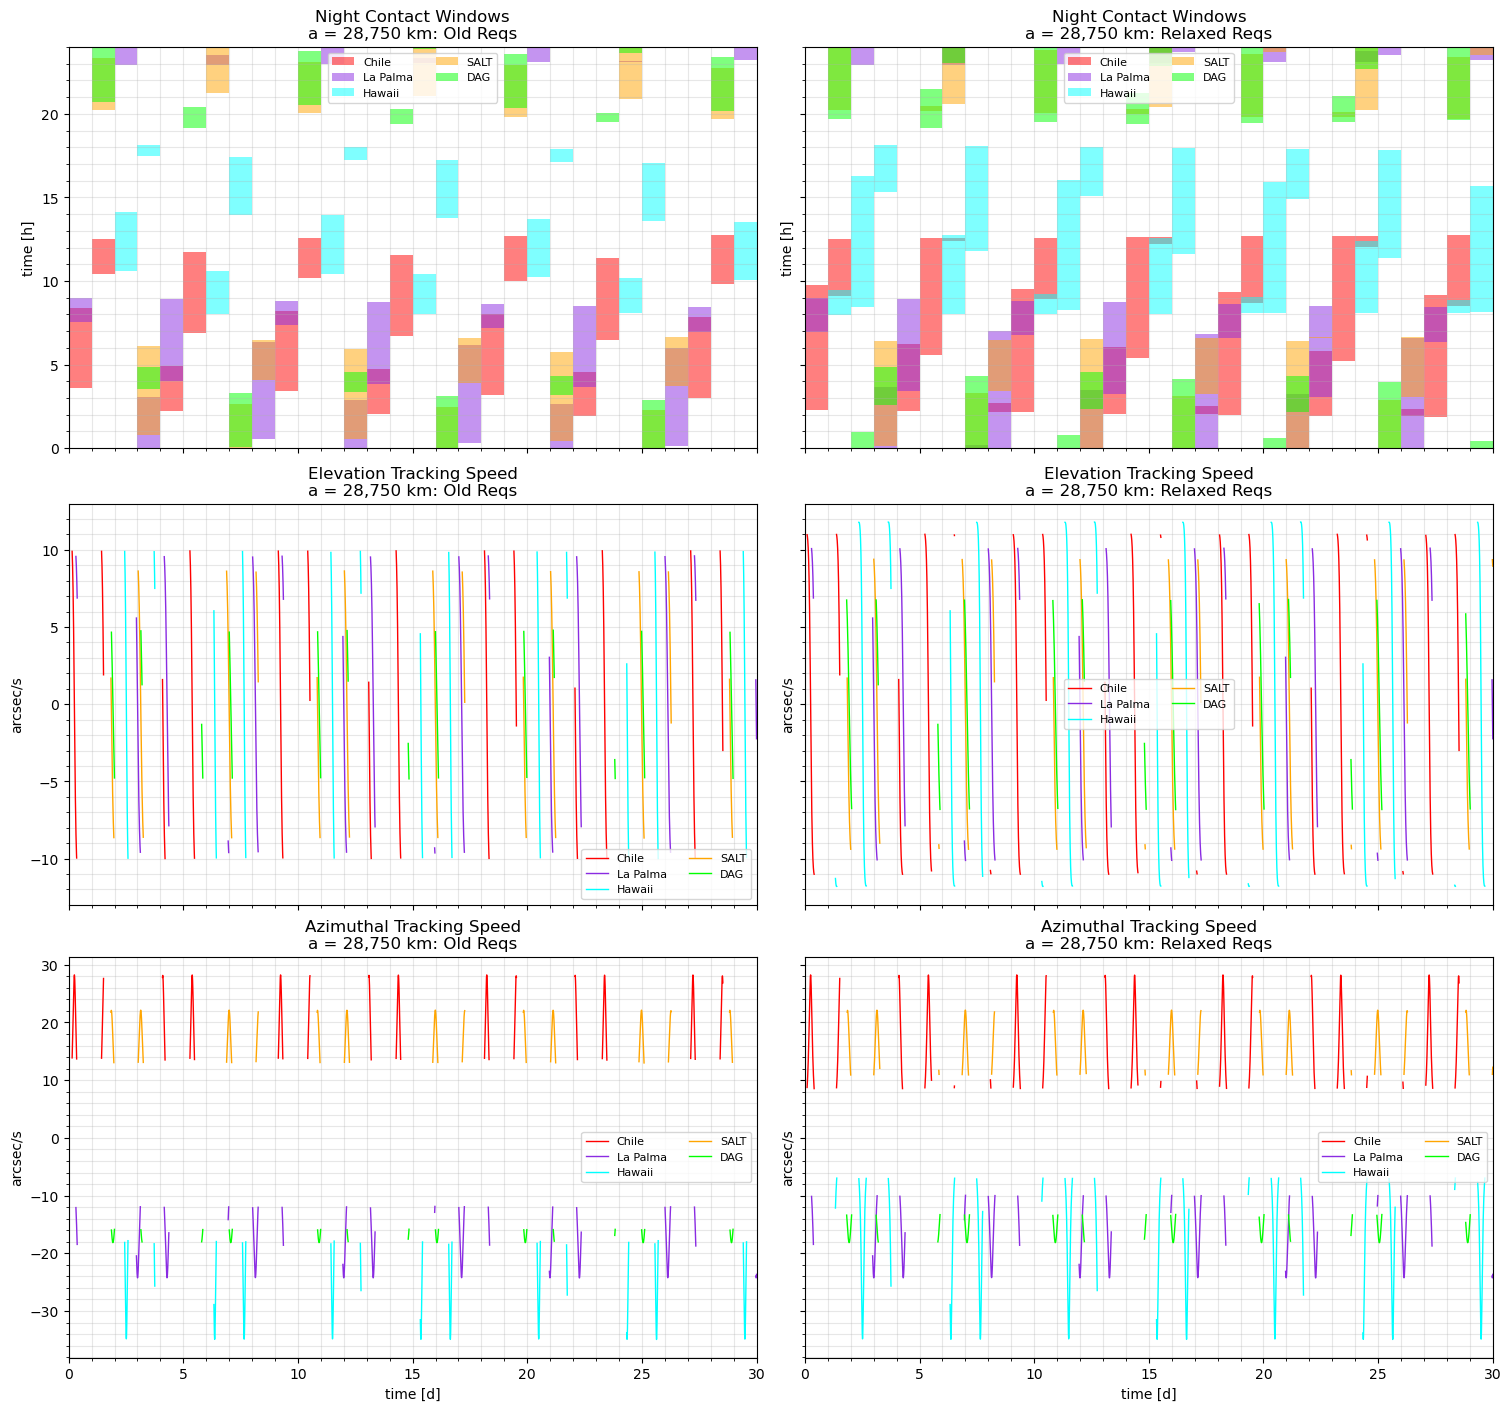

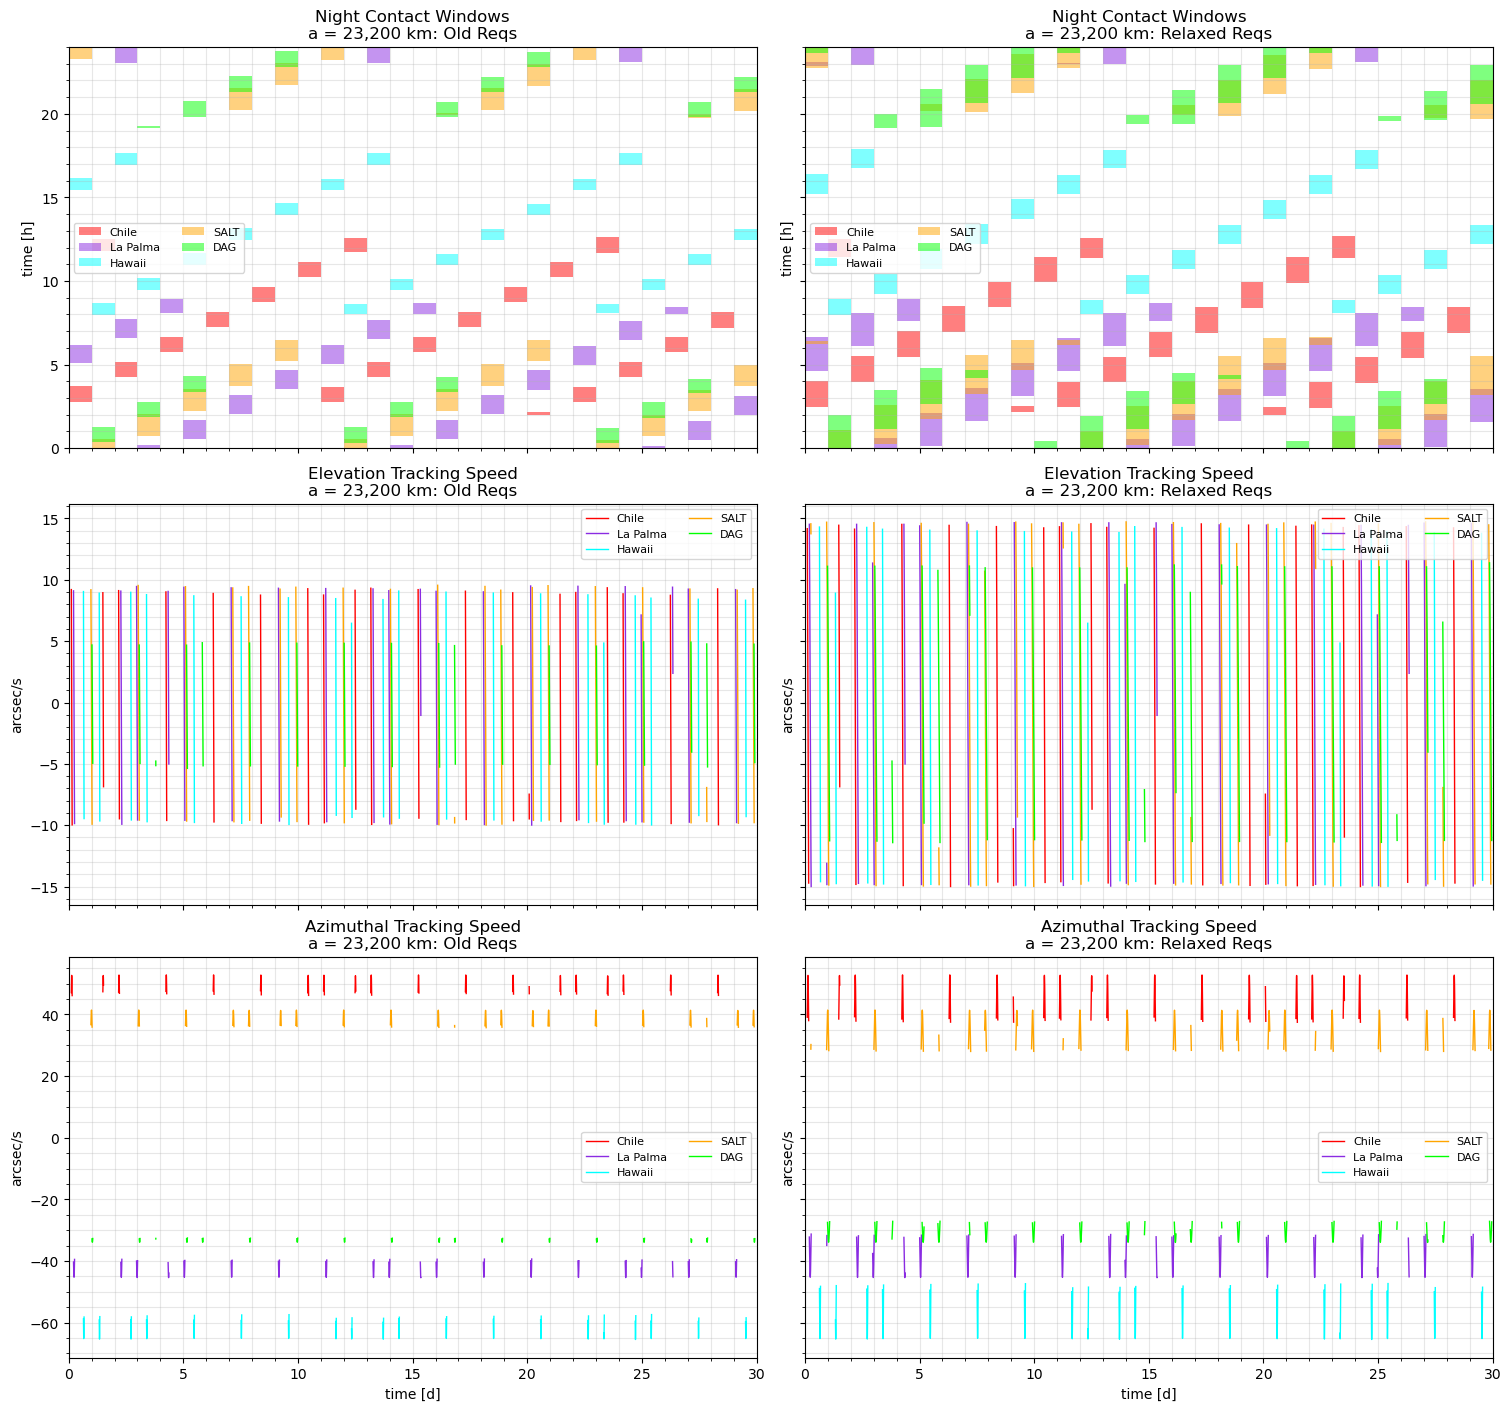

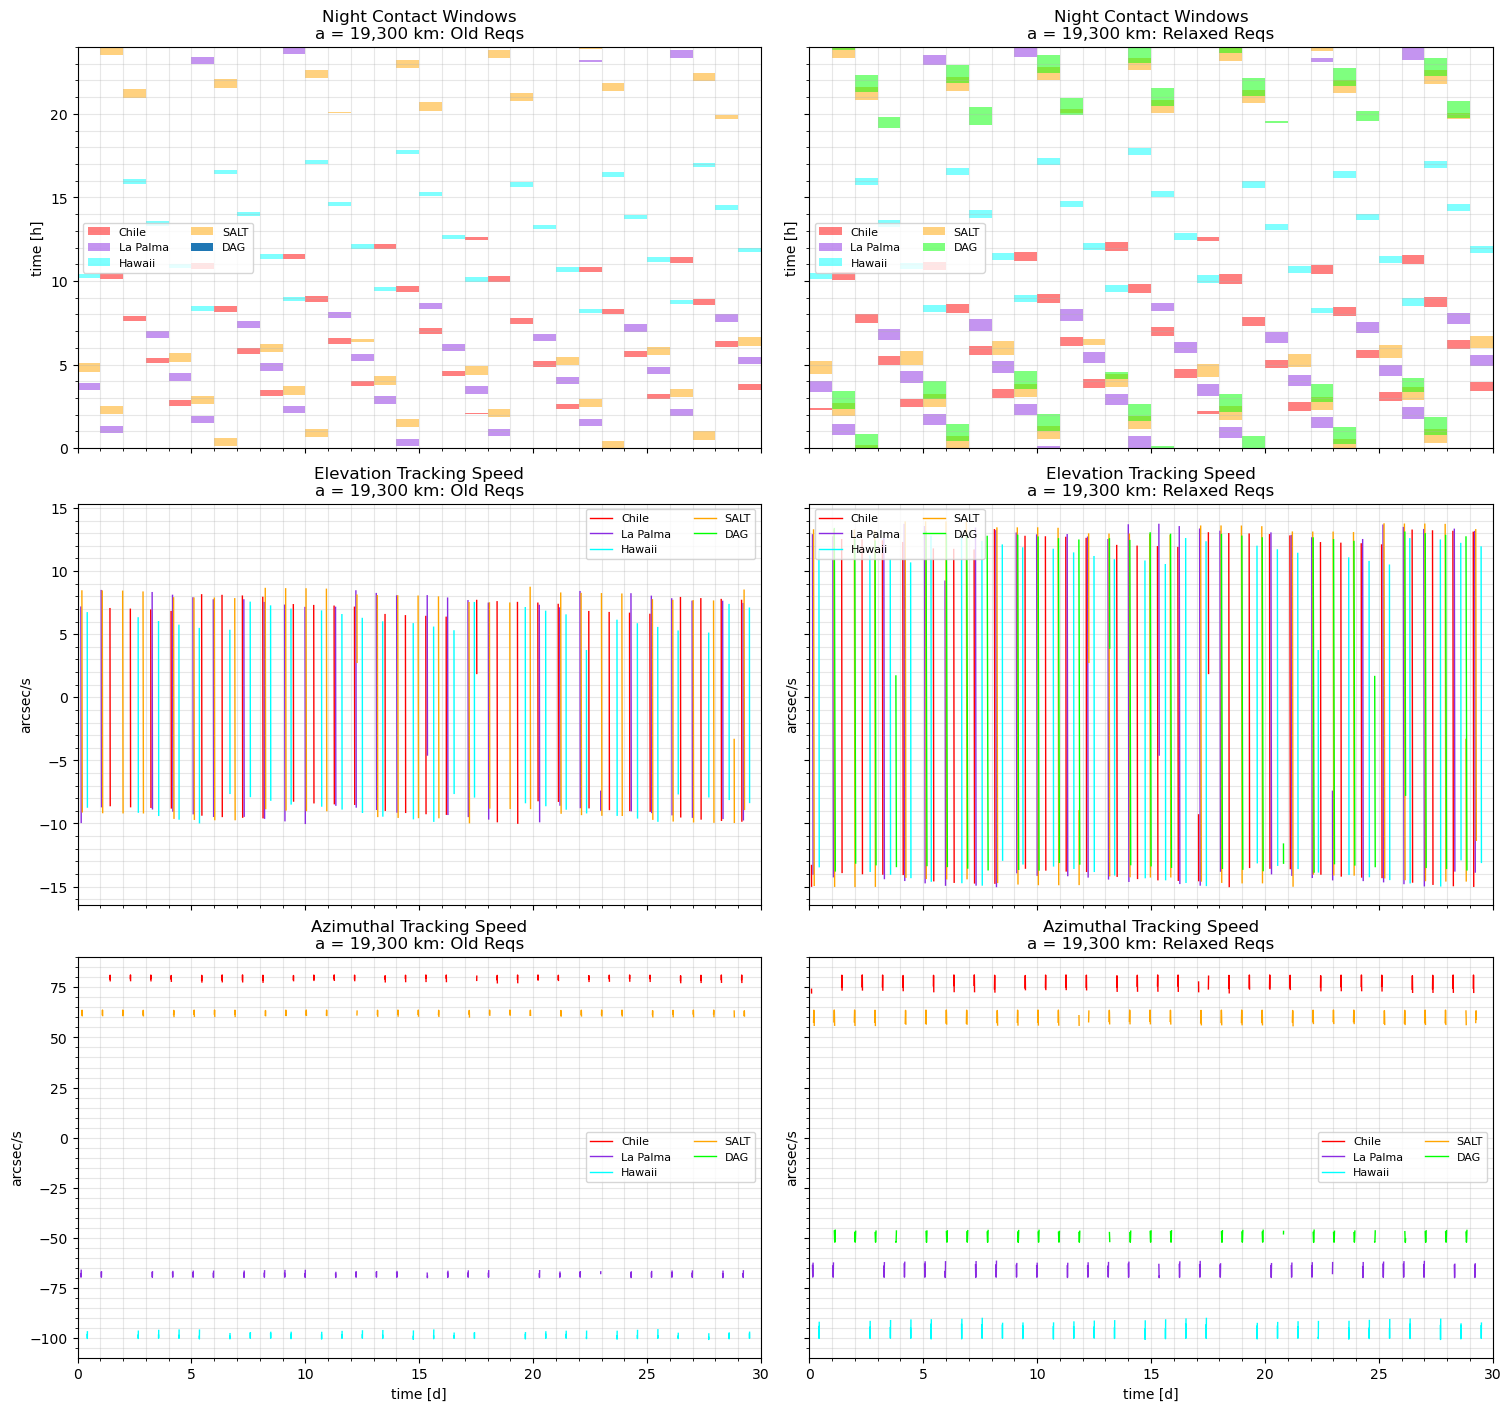

In [ ]:
def plot_contact_windows(ax, folder, title):
    data = read_result(folder, "InContact.txt")
    data = data[(data[:, 0] >= 0) & (data[:, 0] <= DAYS)]

    time = data[:, 0]
    day = np.floor(time) + 0.5
    hour = (time - np.floor(time)) * 24
    dt_hours = np.median(np.diff(time)) * 24

    for i, station in enumerate(stations):
        visible = data[:, i + 1] == 1
        ax.bar(day[visible], np.full(visible.sum(), dt_hours),
               width=1, bottom=hour[visible],
               color=colors[i], alpha=0.5, label=station)

    ax.set_title(title)
    ax.set_ylabel("time [h]")
    ax.set_xlim(0, DAYS)
    ax.set_ylim(0, 24)
    ax.minorticks_on()
    ax.grid(which="both", alpha=0.3)
    ax.legend(fontsize=8, ncol=2)


def plot_speed(ax, folder, filename, title, requirement=None):
    data = read_result(folder, filename)
    data = data[(data[:, 0] >= 0) & (data[:, 0] <= DAYS)]

    time = data[:, 0]
    values = data[:, 1:].copy()

    # Ignore zeros outside contact windows
    values[values == 0] = np.nan

    for i, station in enumerate(stations):
        ax.plot(time, values[:, i], color=colors[i],
                linewidth=1, label=station)

    # Optional horizontal line showing the telescope requirement
    if SHOW_REQUIREMENTS and requirement is not None:
        ax.axhline(requirement, color="black", linestyle="--",
                   linewidth=1.2,
                   label=f"Requirement: {requirement:g} arcsec/s")

    ax.set_title(title)
    ax.set_ylabel("arcsec/s")
    ax.set_xlim(0, DAYS)
    ax.minorticks_on()
    ax.grid(which="both", alpha=0.3)
    ax.legend(fontsize=8, ncol=2)


# One figure per semi-major axis; old and relaxed requirements are side by side
for case in cases:
    a = case["a"]

    fig, axes = plt.subplots(
        3, 2,
        figsize=(15, 14),
        sharex=True,
        sharey="row",
        constrained_layout=True)

    for col, (req_name, folder) in enumerate(case["folders"].items()):
        subtitle = f"a = {a:,} km: {req_name}"

        # Elevation limit is 10 arcsec/s for old requirements and 15 for relaxed
        elevation_limit = 10 if req_name == "Old Reqs" else 15

        plot_contact_windows(
            axes[0, col], folder,
            f"Night Contact Windows\n{subtitle}")

        plot_speed(
            axes[1, col], folder,
            "Elevation Speed.txt",
            f"Elevation Tracking Speed\n{subtitle}",
            requirement=elevation_limit)

        plot_speed(
            axes[2, col], folder,
            "Azimuthal Speed.txt",
            f"Azimuthal Tracking Speed\n{subtitle}",
            requirement=600)

        axes[2, col].set_xlabel("time [d]")

    # Change SAVE_FIGURES to True to save each figure
    if SAVE_FIGURES:
        output = BASE / "comparison_plots"
        output.mkdir(exist_ok=True)

        fig.savefig(
            output / f"comparison_a{a}.png",
            dpi=300,
            bbox_inches="tight")

    plt.show()

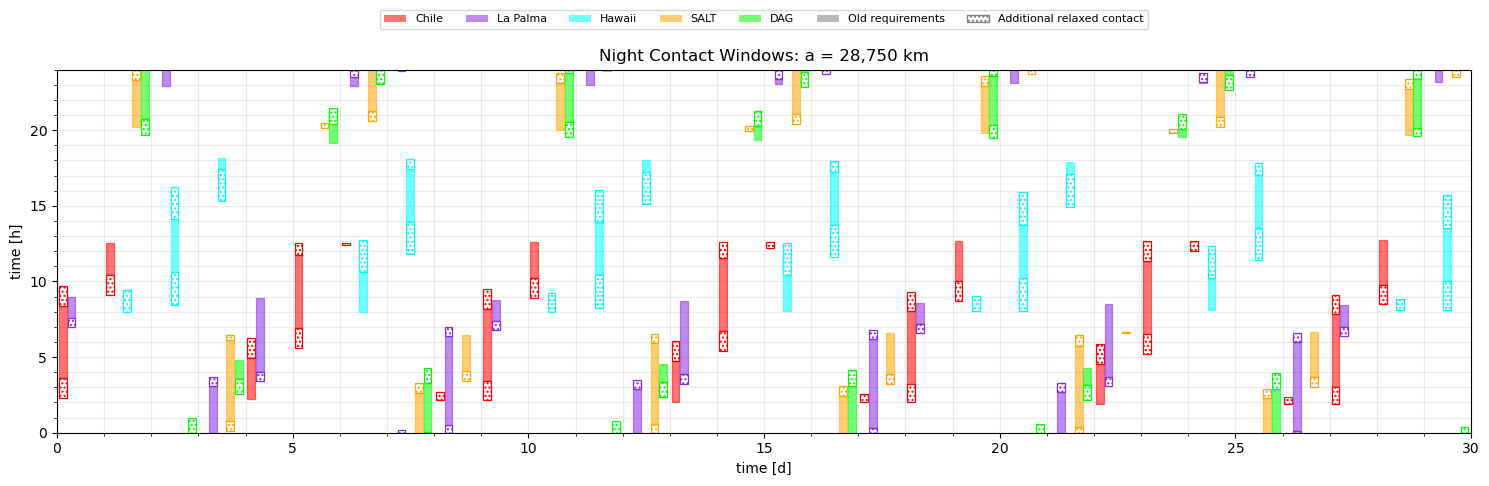

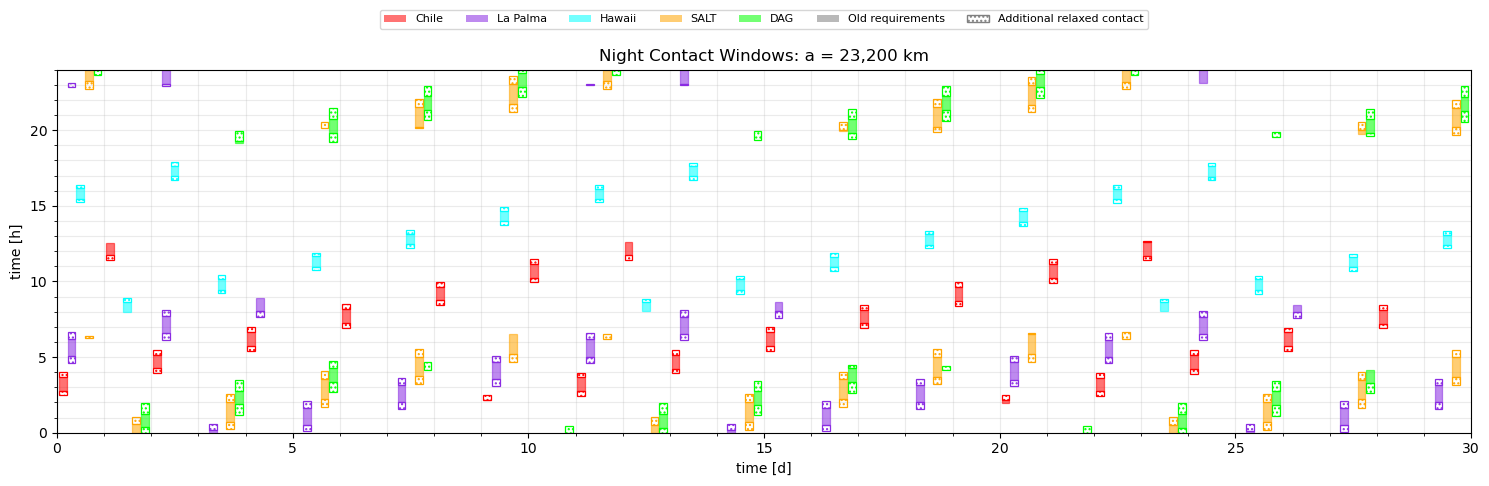

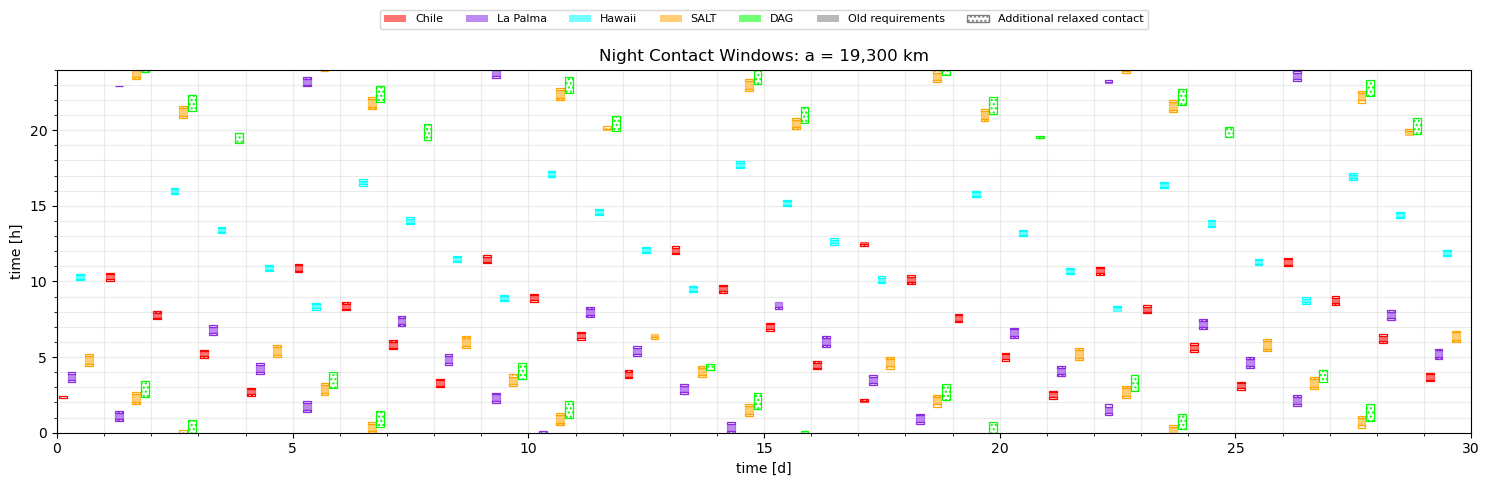

In [22]:
from matplotlib.patches import Patch, Rectangle

SELECTED_TELESCOPES = ["Chile", "La Palma", "Hawaii", "SALT", "DAG"]
RELAXED_HATCH = "...."


def get_contact_segments(time, visible):
    """Return contact segments as (day, start hour, duration hours)."""
    dt = np.median(np.diff(time))
    padded = np.r_[False, visible, False]

    starts = np.where(np.diff(padded.astype(int)) == 1)[0]
    ends = np.where(np.diff(padded.astype(int)) == -1)[0]

    segments = []

    for start, end in zip(starts, ends):
        t_start = time[start]
        t_end = min(time[end - 1] + dt, DAYS)

        # Split contacts crossing midnight
        while t_start < t_end:
            day = int(np.floor(t_start))
            segment_end = min(t_end, day + 1)

            segments.append((
                day,
                (t_start - day) * 24,
                (segment_end - t_start) * 24))

            t_start = segment_end

    return segments


def draw_segments(ax, segments, x_position, width, color,
                  solid=True, hatch=None):
    for day, start_hour, duration in segments:
        ax.add_patch(Rectangle(
            (day + x_position, start_hour),
            width,
            duration,
            facecolor=color if solid else "none",
            edgecolor=color,
            alpha=0.55 if solid else 1,
            hatch=hatch,
            linewidth=0.9))


# Telescope and requirement legend
legend_handles = [
    Patch(facecolor=colors[stations.index(station)],
          alpha=0.55, label=station)
    for station in SELECTED_TELESCOPES]

legend_handles += [
    Patch(facecolor="grey", alpha=0.55, label="Old requirements"),
    Patch(facecolor="none", edgecolor="grey",
          hatch=RELAXED_HATCH, label="Additional relaxed contact")]


# One separate figure for each semi-major axis
for case in cases:
    old_data = read_result(
        case["folders"]["Old Reqs"], "InContact.txt")
    relaxed_data = read_result(
        case["folders"]["Relaxed Reqs"], "InContact.txt")

    old_data = old_data[
        (old_data[:, 0] >= 0) & (old_data[:, 0] < DAYS)]
    relaxed_data = relaxed_data[
        (relaxed_data[:, 0] >= 0) & (relaxed_data[:, 0] < DAYS)]

    if old_data.shape != relaxed_data.shape or not np.allclose(
        old_data[:, 0], relaxed_data[:, 0]):
        raise ValueError(
            f"Time grids do not match for a = {case['a']:,} km.")

    time = old_data[:, 0]

    fig, ax = plt.subplots(figsize=(15, 5))

    # Divide each day into one narrow lane per telescope
    lane_width = 0.92 / len(SELECTED_TELESCOPES)
    rectangle_width = 0.9 * lane_width

    for j, station in enumerate(SELECTED_TELESCOPES):
        i = stations.index(station)
        color = colors[i]

        old_visible = old_data[:, i + 1] == 1
        relaxed_visible = relaxed_data[:, i + 1] == 1

        # Show only the visibility gained by relaxing the requirements
        relaxed_only = relaxed_visible & ~old_visible

        old_segments = get_contact_segments(time, old_visible)
        relaxed_segments = get_contact_segments(time, relaxed_only)

        x_position = 0.04 + j * lane_width

        draw_segments(
            ax, old_segments, x_position,
            rectangle_width, color, solid=True)

        draw_segments(
            ax, relaxed_segments, x_position,
            rectangle_width, color,
            solid=False, hatch=RELAXED_HATCH)

    ax.set_title(f"Night Contact Windows: a = {case['a']:,} km")
    ax.set_xlabel("time [d]")
    ax.set_ylabel("time [h]")
    ax.set_xlim(0, DAYS)
    ax.set_ylim(0, 24)
    ax.set_xticks(np.arange(0, DAYS + 1, 5))
    ax.set_yticks(np.arange(0, 25, 5))
    ax.minorticks_on()
    ax.grid(which="both", alpha=0.25)
    ax.set_axisbelow(True)

    ax.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.18),
        ncol=len(legend_handles),
        fontsize=8)

    plt.tight_layout()

    if SAVE_FIGURES:
        output = BASE / "comparison_plots"
        output.mkdir(exist_ok=True)

        fig.savefig(
            output / f"contact_windows_comparison_a{case['a']}.png",
            dpi=300,
            bbox_inches="tight")

    plt.show()

In [ ]:
MU_EARTH = 398600.4418  # Earth's gravitational parameter [km^3/s^2]


def contact_statistics(folder):
    data = read_result(folder, "InContact.txt")
    data = data[(data[:, 0] >= 0) & (data[:, 0] <= DAYS)]

    time = data[:, 0]            # Elapsed simulation time [days]
    in_contact = data[:, 1:] == 1  # One Boolean column per telescope

    # A new contact window begins whenever InContact changes from 0 to 1.
    # The first row is compared with an initial value of 0, so a contact already active at the start of the selected period is counted.
    previous = np.vstack((
        np.zeros((1, in_contact.shape[1]), dtype=bool),
        in_contact[:-1]))
    contact_starts = in_contact & ~previous

    duration_days = time[-1] - time[0]

    # Count the contact-window starts for each telescope, then divide by the simulation duration to obtain contacts/day for each telescope.
    contacts_per_day_per_telescope = contact_starts.sum(axis=0) / duration_days

    # The table reports the mean contacts/day across the five telescopes.
    mean_contacts_per_day = contacts_per_day_per_telescope.mean()

    # Convert the mean contact rate into an equivalent average interval: interval [h] = 24 [h/day] / contacts [contacts/day].
    # This is derived from the mean rate, not from the individual time gaps.
    mean_interval_hours = (
        24 / mean_contacts_per_day
        if mean_contacts_per_day > 0 else np.nan)

    return mean_contacts_per_day, mean_interval_hours


def tracking_speed_range(folder):
    data = read_result(folder, "Tracking Speed.txt")
    data = data[(data[:, 0] >= 0) & (data[:, 0] <= DAYS)]

    maxima = []

    # Find the largest non-zero absolute tracking speed for each telescope.
    for values in data[:, 1:].T:
        values = np.abs(values[np.isfinite(values) & (values != 0)])

        if values.size:
            maxima.append(values.max())

    # Return the range of telescope-specific maximum tracking speeds.
    return min(maxima), max(maxima)


def fmt(value, decimals=2):
    # Remove unnecessary trailing zeros from displayed values.
    return f"{value:.{decimals}f}".rstrip("0").rstrip(".")


columns = {}

for case in cases:
    a = case["a"]

    # Circular-orbit period calculated using Kepler's third law.
    period_hours = 2 * np.pi * np.sqrt(a**3 / MU_EARTH) / 3600

    for req_name, folder in case["folders"].items():
        contacts_per_day, interval_hours = contact_statistics(folder)
        speed_min, speed_max = tracking_speed_range(folder)

        columns[(case["name"], req_name)] = [
            f"{a:,} km",
            f"{period_hours:.3f} h",
            "0°",
            f"{contacts_per_day:.3f}",
            f"{interval_hours:.2f} h",
            f"{fmt(speed_min)} – {fmt(speed_max)} arcsec/s"]


# Each case has two columns: old requirements and relaxed requirements.
summary = pd.DataFrame(columns, index=[
    "Semi-major axis",
    "Orbit period",
    "Orbit inclination",
    "Mean night contacts/day per telescope",
    "Equivalent mean interval between night contacts",
    "Max. tracking speed for different latitudes"])

summary.columns = pd.MultiIndex.from_tuples(summary.columns)
summary.index.name = "Orbit"

table_styles = [
    {"selector": "th", "props": [
        ("text-align", "center"),
        ("font-weight", "bold"),
        ("border", "1px solid black")]},
    {"selector": "td", "props": [
        ("text-align", "center"),
        ("border", "1px solid black")]}]

display(summary.style.set_table_styles(table_styles))

##### Mean contacts/day per telescope: how many valid night contacts does one telescope obtain per day on average. It is not the total number of contacts produced by the full network.
##### The inverse of a rate in contacts/day gives days/contact. Multiplying by 24 gives the equivalent interval in hours. For example, 0.473 contacts/day gives 24 / 0.473 = 50.70 h. This is a rate-derived equivalent interval. It is not the arithmetic mean of the actual time gaps between consecutive contact starts. If contact spacing is irregular, those two quantities can differ.
##### If the five station maxima are 13.87, 14.02, 14.31, 14.55 and 14.71 arcsec/s, the table reports 13.87-14.71 arcsec/s. This is the range of station-specific maxima, not the minimum and maximum of every tracking-speed sample in the simulation.

##### The Table in Chapter 4.2 of Orbit Analysis v1.2 original Contacts/day and Interval between contacts values were the theoretical equatorial synodic recurrence values, which depend only on the orbit and would therefore be identical for the old and relaxed requirements. The code above instead measures completed night-contact windows from each simulation, making it more useful for this comparison.

##### The calculation of the theoretical synodic period values is done below to ensure results match with Orbit Analysis v1.2 document.

In [ ]:
MU_EARTH = 398600.4418       # Earth's gravitational parameter [km^3/s^2]
EARTH_ROTATION_HOURS = 23.9344696  # Sidereal rotation period [h]


def theoretical_contact_statistics(period_hours):
    # For a prograde equatorial orbit, contact geometry repeats according to the relative angular motion of the spacecraft and the rotating Earth.
    synodic_period_hours = 1 / abs(
        1 / period_hours - 1 / EARTH_ROTATION_HOURS)

    # The original table defines contacts/day as the number of theoretical recurrence intervals contained in one 24-hour day.
    contacts_per_day = 24 / synodic_period_hours

    # This interval is theoretical and depends only on the orbital period.
    # It does not account for nighttime, minimum elevation, tracking limits, telescope longitude, or whether an actual contact is completed.
    return contacts_per_day, synodic_period_hours


def tracking_speed_range(folder):
    data = read_result(folder, "Tracking Speed.txt")
    data = data[(data[:, 0] >= 0) & (data[:, 0] <= DAYS)]

    maxima = []

    # Maximum non-zero absolute tracking speed reached by each telescope.
    for values in data[:, 1:].T:
        values = np.abs(values[np.isfinite(values) & (values != 0)])

        if values.size:
            maxima.append(values.max())

    # Range between the five telescope-specific maximum values.
    return min(maxima), max(maxima)


def fmt(value, decimals=2):
    return f"{value:.{decimals}f}".rstrip("0").rstrip(".")


columns = {}

for case in cases:
    a = case["a"]

    # Circular-orbit period from Kepler's third law.
    period_hours = 2 * np.pi * np.sqrt(a**3 / MU_EARTH) / 3600

    # These values depend only on the orbit, so they are identical for the old and relaxed telescope requirements.
    contacts_per_day, interval_hours = theoretical_contact_statistics(
        period_hours)

    for req_name, folder in case["folders"].items():
        speed_min, speed_max = tracking_speed_range(folder)

        columns[(case["name"], req_name)] = [
            f"{a:,} km",
            f"{period_hours:.3f} h",
            "0°",
            f"{contacts_per_day:.3f}",
            f"{interval_hours:.2f} h",
            f"{fmt(speed_min)} – {fmt(speed_max)} arcsec/s"]


summary = pd.DataFrame(columns, index=[
    "Semi-major axis",
    "Orbit period",
    "Orbit inclination",
    "Theoretical contacts/day",
    "Theoretical interval between contacts",
    "Max. tracking speed for different latitudes"])

summary.columns = pd.MultiIndex.from_tuples(summary.columns)
summary.index.name = "Orbit"

table_styles = [
    {"selector": "th", "props": [
        ("text-align", "center"),
        ("font-weight", "bold"),
        ("border", "1px solid black")]},
    {"selector": "td", "props": [
        ("text-align", "center"),
        ("border", "1px solid black")]}]

display(summary.style.set_table_styles(table_styles))

### Summary: The synodic method computes an idealised recurrence from the relative angular motion of a prograde equatorial spacecraft and the rotating Earth. It reproduces the original table because it does not apply telescope constraints. The simulation-statistics method detects 0-to-1 transitions in each telescope's InContact history, divides the event count by the analysed duration, averages the rates across stations, and converts the mean rate into an equivalent interval. This second method is the more accurate representation of usable telescope visibility under the old and relaxed requirements.

In [ ]:
# Telescopes to include in the statistics
SELECTED_TELESCOPES = ["Chile", "La Palma", "Hawaii", "SALT", "DAG"]


def contact_intervals(time, visible):
    """Return the start and end time of every continuous contact window."""
    dt = np.median(np.diff(time))
    end_of_data = time[-1] + dt

    # Detect transitions into and out of contact
    changes = np.diff(visible.astype(int))
    starts = list(time[1:][changes == 1])
    ends = list(time[1:][changes == -1])

    # Include contacts already active at the start or end of the data
    if visible[0]:
        starts.insert(0, time[0])
    if visible[-1]:
        ends.append(end_of_data)

    return np.array(starts), np.array(ends), end_of_data


def visibility_statistics(time, visible):
    starts, ends, end_of_data = contact_intervals(time, visible)

    # Duration of each continuous contact window [h]
    durations = (ends - starts) * 24

    if durations.size:
        median_duration = np.median(durations)
        maximum_duration = np.max(durations)
        total_contact = np.sum(durations)
    else:
        median_duration = np.nan
        maximum_duration = np.nan
        total_contact = 0.0

    # Gaps include the beginning and end of the selected simulation period
    if starts.size:
        gaps = [starts[0] - time[0]]
        gaps.extend(starts[1:] - ends[:-1])
        gaps.append(end_of_data - ends[-1])
        maximum_gap = np.max(gaps) * 24
    else:
        maximum_gap = (end_of_data - time[0]) * 24

    return {
        "total_contact_h": total_contact,
        "median_duration_h": median_duration,
        "maximum_duration_h": maximum_duration,
        "maximum_gap_h": maximum_gap
    }


rows = []

for case in cases:
    old_folder = case["folders"]["Old Reqs"]
    relaxed_folder = case["folders"]["Relaxed Reqs"]

    old_data = read_result(old_folder, "InContact.txt")
    relaxed_data = read_result(relaxed_folder, "InContact.txt")

    # Restrict both simulations to the selected analysis period
    old_data = old_data[(old_data[:, 0] >= 0) & (old_data[:, 0] <= DAYS)]
    relaxed_data = relaxed_data[
        (relaxed_data[:, 0] >= 0) & (relaxed_data[:, 0] <= DAYS)]

    # Statistics require matching output times
    if old_data.shape != relaxed_data.shape or not np.allclose(
        old_data[:, 0], relaxed_data[:, 0]):
        raise ValueError(
            f"Old and relaxed time grids do not match for a = {case['a']:,} km.")

    time = old_data[:, 0]

    for station in SELECTED_TELESCOPES:
        i = stations.index(station)

        old_visible = old_data[:, i + 1] == 1
        relaxed_visible = relaxed_data[:, i + 1] == 1

        old_stats = visibility_statistics(time, old_visible)
        relaxed_stats = visibility_statistics(time, relaxed_visible)

        # Integrate only timesteps newly accepted by the relaxed requirements
        dt_hours = np.median(np.diff(time)) * 24
        relaxed_only = relaxed_visible & ~old_visible
        additional_hours = relaxed_only.sum() * dt_hours

        increase_percent = (
            100 * additional_hours / old_stats["total_contact_h"]
            if old_stats["total_contact_h"] > 0 else np.nan)

        rows.append({
            "Semi-major axis [km]": case["a"],
            "Telescope": station,
            "Old total contact [h]": old_stats["total_contact_h"],
            "Relaxed total contact [h]": relaxed_stats["total_contact_h"],
            "Additional contact [h]": additional_hours,
            "Contact increase [%]": increase_percent,
            "Old median duration [h]": old_stats["median_duration_h"],
            "Relaxed median duration [h]": relaxed_stats["median_duration_h"],
            "Old maximum duration [h]": old_stats["maximum_duration_h"],
            "Relaxed maximum duration [h]": relaxed_stats["maximum_duration_h"],
            "Old maximum gap [h]": old_stats["maximum_gap_h"],
            "Relaxed maximum gap [h]": relaxed_stats["maximum_gap_h"]})


contact_stats = pd.DataFrame(rows).round(2)
display(contact_stats)

,Semi-major axis [km],Telescope,Old total contact [h],Relaxed total contact [h],Additional contact [h],Contact increase [%],Old median duration [h],Relaxed median duration [h],Old maximum duration [h],Relaxed maximum duration [h],Old maximum gap [h],Relaxed maximum gap [h]
0,28750,Chile,52.03,81.10,29.10,55.93,2.93,3.98,4.87,7.47,87.67,61.67
1,28750,La Palma,51.27,62.77,11.50,22.43,3.57,4.17,5.87,7.07,62.77,62.77
2,28750,Hawaii,33.83,76.93,43.10,127.39,3.47,4.53,3.53,7.83,89.00,62.27
3,28750,SALT,52.57,66.17,13.60,25.87,3.10,3.75,5.37,6.70,87.13,61.73
4,28750,DAG,28.93,48.53,19.60,67.74,3.23,4.77,3.23,5.27,89.27,87.70
5,23200,Chile,17.30,29.23,11.93,68.98,0.90,1.53,0.93,1.57,48.60,47.97
6,23200,La Palma,21.10,35.97,14.87,70.46,1.13,1.97,1.17,2.00,48.37,47.53
7,23200,Hawaii,13.63,22.27,8.63,63.33,0.70,1.17,0.70,1.17,48.83,48.37
8,23200,SALT,25.10,45.43,20.33,81.01,1.30,2.33,1.33,2.33,48.20,47.17
9,23200,DAG,15.63,39.20,23.57,150.75,0.92,2.27,0.93,2.33,48.60,47.23


In [19]:
summary_stats = (
    contact_stats
    .groupby("Semi-major axis [km]", as_index=False)
    .mean(numeric_only=True)
    .round(2))

display(summary_stats)

,Semi-major axis [km],Old total contact [h],Relaxed total contact [h],Additional contact [h],Contact increase [%],Old median duration [h],Relaxed median duration [h],Old maximum duration [h],Relaxed maximum duration [h],Old maximum gap [h],Relaxed maximum gap [h]
0,19300,8.75,19.22,10.47,57.62,0.38,0.69,0.39,0.72,178.48,44.39
1,23200,18.55,34.42,15.87,86.91,0.99,1.85,1.01,1.88,48.52,47.65
2,28750,43.73,67.10,23.38,59.87,3.26,4.24,4.57,6.87,83.17,67.23
